In [6]:
# Restaurant Feedback Analysis using NLP
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download Required NLTK Files
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
# Step 1 : Collect Restaurant Feedback Data
# ==========================================

data = {
    "Review": [
        "The food was delicious and delivery was very fast.",
        "The pizza was cold and the packaging was poor.",
        "Excellent customer service and tasty food.",
        "Delivery was late and the food was not fresh.",
        "Amazing burger and worth the price.",
        "Very bad experience. The food was stale.",
        "Fast delivery and good packaging.",
        "The waiter was polite and the restaurant was clean.",
        "Excellent taste and friendly staff.",
        "The order arrived late and customer support was unhelpful."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display Dataset
print("Restaurant Feedback Dataset")
print(df)


Restaurant Feedback Dataset
                                              Review
0  The food was delicious and delivery was very f...
1     The pizza was cold and the packaging was poor.
2         Excellent customer service and tasty food.
3      Delivery was late and the food was not fresh.
4                Amazing burger and worth the price.
5           Very bad experience. The food was stale.
6                  Fast delivery and good packaging.
7  The waiter was polite and the restaurant was c...
8                Excellent taste and friendly staff.
9  The order arrived late and customer support wa...


In [8]:
# Step 2 : Clean and Preprocess Text
# ==========================================

stop_words = set(stopwords.words('english'))

def Clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply Cleaning
df["Cleaned_Review"] = df["Review"].apply(Clean_text)

print("\nCleaned Reviews\n")
print(df["Cleaned_Review"])



Cleaned Reviews

0                     food delicious delivery fast
1                        pizza cold packaging poor
2            excellent customer service tasty food
3                         delivery late food fresh
4                       amazing burger worth price
5                        bad experience food stale
6                     fast delivery good packaging
7                   waiter polite restaurant clean
8                   excellent taste friendly staff
9    order arrived late customer support unhelpful
Name: Cleaned_Review, dtype: object


In [9]:
# Step 3 : Perform Sentiment Classification
# ==========================================

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply Sentiment Analysis
df["Sentiment"] = df["Cleaned_Review"].apply(analyze_sentiment)

print("\nSentiment Classification\n")
print(df[["Review", "Sentiment"]])


Sentiment Classification

                                              Review Sentiment
0  The food was delicious and delivery was very f...  Positive
1     The pizza was cold and the packaging was poor.  Negative
2         Excellent customer service and tasty food.  Positive
3      Delivery was late and the food was not fresh.  Positive
4                Amazing burger and worth the price.  Positive
5           Very bad experience. The food was stale.  Negative
6                  Fast delivery and good packaging.  Positive
7  The waiter was polite and the restaurant was c...  Positive
8                Excellent taste and friendly staff.  Positive
9  The order arrived late and customer support wa...  Positive


In [10]:
# Step 4 : Identify Common Keywords
# ==========================================

all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))

# ==========================================
# Step 5 : Identify Common Service Issues
# ==========================================

negative_reviews = df[df["Sentiment"] == "Negative"]

negative_words = " ".join(negative_reviews["Cleaned_Review"])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\nCommon Service Issue Keywords")
print(complaint_freq.most_common(10))



Top 10 Common Keywords
[('food', 4), ('delivery', 3), ('fast', 2), ('packaging', 2), ('excellent', 2), ('customer', 2), ('late', 2), ('delicious', 1), ('pizza', 1), ('cold', 1)]

Common Service Issue Keywords
[('pizza', 1), ('cold', 1), ('packaging', 1), ('poor', 1), ('bad', 1), ('experience', 1), ('food', 1), ('stale', 1)]



Final Processed Dataset

                                              Review  \
0  The food was delicious and delivery was very f...   
1     The pizza was cold and the packaging was poor.   
2         Excellent customer service and tasty food.   
3      Delivery was late and the food was not fresh.   
4                Amazing burger and worth the price.   
5           Very bad experience. The food was stale.   
6                  Fast delivery and good packaging.   
7  The waiter was polite and the restaurant was c...   
8                Excellent taste and friendly staff.   
9  The order arrived late and customer support wa...   

                                  Cleaned_Review Sentiment  
0                   food delicious delivery fast  Positive  
1                      pizza cold packaging poor  Negative  
2          excellent customer service tasty food  Positive  
3                       delivery late food fresh  Positive  
4                     amazing burger worth price  Po

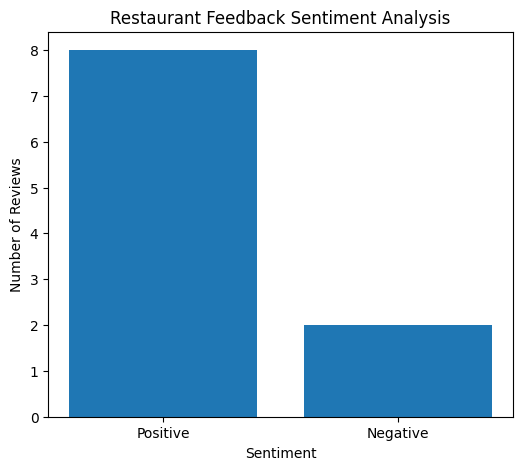

In [11]:
# Step 6 : Display Final Dataset
# ==========================================

print("\nFinal Processed Dataset\n")
print(df)

# ==========================================
# Step 7 : Sentiment Graph
# ==========================================

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Restaurant Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

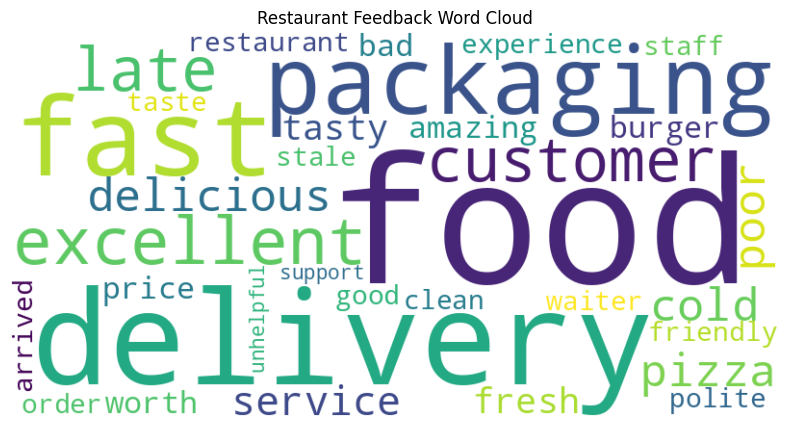

In [12]:
# Step 8 : Word Cloud
# ==========================================

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Restaurant Feedback Word Cloud")
plt.show()


In [13]:
# Step 9 : Feedback Analysis Report
# ==========================================

print("\nFeedback Analysis Report")
print("--------------------------------")

positive_count = len(df[df["Sentiment"] == "Positive"])
negative_count = len(df[df["Sentiment"] == "Negative"])
neutral_count = len(df[df["Sentiment"] == "Neutral"])

print("Total Reviews :", len(df))
print("Positive Reviews :", positive_count)
print("Negative Reviews :", negative_count)
print("Neutral Reviews :", neutral_count)

print("\nCommon Positive Areas:")
print("- Delicious food")
print("- Fast delivery")
print("- Friendly staff")
print("- Good packaging")

print("\nCommon Service Issues:")
print("- Late delivery")
print("- Cold food")
print("- Poor packaging")
print("- Stale food")
print("- Poor customer support")

print("\nTop Complaint Keywords:")
for word, count in complaint_freq.most_common(5):
    print(f"{word} : {count}")

print("\nRecommendations:")
print("1. Improve food quality and freshness.")
print("2. Reduce delivery delays.")
print("3. Improve food packaging.")
print("4. Train customer support staff.")
print("5. Maintain restaurant hygiene and service quality.")


Feedback Analysis Report
--------------------------------
Total Reviews : 10
Positive Reviews : 8
Negative Reviews : 2
Neutral Reviews : 0

Common Positive Areas:
- Delicious food
- Fast delivery
- Friendly staff
- Good packaging

Common Service Issues:
- Late delivery
- Cold food
- Poor packaging
- Stale food
- Poor customer support

Top Complaint Keywords:
pizza : 1
cold : 1
packaging : 1
poor : 1
bad : 1

Recommendations:
1. Improve food quality and freshness.
2. Reduce delivery delays.
3. Improve food packaging.
4. Train customer support staff.
5. Maintain restaurant hygiene and service quality.
